# **NYC Citi-Bike Ridership & 311 Service Request Analysis**

Miles Whiteford & Aaron Gershkovich

[Link to Github Page](https://mileswhiteford.github.io/)

# **Project Goals:**
 For this project we want to explore how service request activity, through 311 calls, affect Bike Ride Share usage in New York City. We are curious about the number and types of complaints that come out from a given neighborhood, such as road closures and accidents, impact the use of bikes in these areas. We will also study the bike data set independently, identifying common hubs of travel where new stations should potentially be opened up or where the flux of bikes require frequent bike refilling. We can also see how ridership changes based on demographic population as age, gender, and user type are also recorded. Overall, we think this is a very unique and interesting data set because it gets at the question of how the quality of neighborhood facilities impact more environmentally conscious travel choices. We can also draw conclusions on certain demographical data that could allow us to determine target users in certain neighborhoods

#**Project Datasets**
**Dataset 1: New York City Citi Bike Data from December 2019**

Source: https://s3.amazonaws.com/tripdata/index.html (2019-citibike-tripdata.zip)

This dataset has one row for every citibike ride taken in December of 2019. This includes 15 columns of information including a description of the ride as well as of the account that took the ride. We are using this data because it includes birth year and gender which was removed from future data releases which gives us the chance to know more information about the riders themselves.

The Columns Are:
* Ride ID
* Rideable type
* Started at
* Ended at
* Start station name
* Start station ID
* End station name
* End station ID
* Start latitude
* Start longitude
* End latitude
* End Longitude
* Member or casual ride

We can begin to start drafting questions like 'Do subscriber and casual rider patterns look different in neighborhoods with more 311 complaints?'

**Dataset 2: New York 311 service Requests**
Source: https://www.kaggle.com/datasets/new-york-city/ny-311-service-requests/data

This 311 dataset covers every non-emergency service request logged by the city of New York, and is one of the largest civic datasets available. It gives a really granular picture of what residents of a certain neighborhood are dealing with from day to day and how this may impact their decisions to use other modes of transportation to get to work. The columns included are:
* Unique Key
* Created Date
* Closed Date
* Agency
* Agency Name
* Complaint Type
* Descriptor
* Location Type
* Incident Zip
* Incident Address

There are questions to be drawn from this dataset too: 'Are there more 311 calls in certain neighborhoods? Do these neighborhoods have more citibike users?"


#**ETL (Extraction, Transform, and Load)**

We are downloading both datasets from Kaggle as CSV files and loading them into pandas DataFrames. Here is what we plan to do to get the data into shape:
* Double check the Trip_Duration_in_min column and recalculate it from Trip Duration (seconds divided by 60) if needed
* Pull out date, hour, day of week, and month as their own columns so we can group by time easily
* Filter the 311 data down to the same year as the bike data and drop any rows that are missing a ZIP code or complaint type
* Flag Gender = 0 (unknown) in the bike data rather than trying to fill it in, and handle missing Birth Year the same way
* Aggregate both datasets to a daily count by ZIP code so we can join them on date and location

The biggest challenge that we would face is converting the longitudinal and lattitudinal data into zipcodes to match with the 311 calls. To connect them we plan to use a NYC ZIP code shapefile and a spatial join to assign each station to a ZIP code, or figure out another way to establish the relationship between location and zip codes. This will let us clearly join the file on date and zip code The 311 dataset is also very large so we will filter it to just the year we need and focus on the complaint types most relevant to biking.

#**Exploratory Data Analysis:**
Using dataset 1, we have 4 summary statistics that we think would be relevant as a starting point for this project.

* Total trip count and average trip duration broken down by User Type (Subscriber vs. Customer), to give us a better picture of how different membership plans affect usage.

* Daily trip volume plotted out over time would give us an idea of when popular bike times are throughout the day and how 311 calls may impact this baseline of usage.

* The most popular start and end station pairs would reveal common commututes and high-traffic routes across the city. When paired with 311 complaint data, this would allow us to assess whether service disruptions like road closures or infrastructure complaints along these routes lead to decreased ridership or changes in travel patterns.

* Bike usage by day of the week helps us find commuter patterns, giving us a clearer picture of when New Yorkers rely on bike share throughout the week.

###**Dataset 1: New York City Citi Bike Data from December 2019**

In [ ]:
# Mount drive to import datasets
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Importing and Cleaning the dataset:**

In [ ]:
import pandas as pd

# Import New York City Citi Bike Data dataset from December 2019 from drive
bike_df = pd.read_csv('/content/drive/MyDrive/Data Science Final Project/201912-citibike-tripdata_1.csv')

# Convert start and stop time to datetime data type
bike_df['starttime'] = pd.to_datetime(bike_df['starttime'])
bike_df['stoptime'] = pd.to_datetime(bike_df['starttime'])

# Convert trip duration into minutes
bike_df['tripduration'] = bike_df['tripduration'] / 60

bike_df.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
0,10.033333,2019-12-01 00:00:05.564,2019-12-01 00:00:05.564,3382,Carroll St & Smith St,40.680611,-73.994758,3304,6 Ave & 9 St,40.668127,-73.983776,41932,Subscriber,1970,1
1,20.100000,2019-12-01 00:00:10.963,2019-12-01 00:00:10.963,362,Broadway & W 37 St,40.751726,-73.987535,500,Broadway & W 51 St,40.762288,-73.983362,18869,Customer,1999,1
2,12.050000,2019-12-01 00:00:11.818,2019-12-01 00:00:11.818,146,Hudson St & Reade St,40.716250,-74.009106,238,Bank St & Washington St,40.736197,-74.008592,15334,Subscriber,1997,1
3,6.733333,2019-12-01 00:00:12.220,2019-12-01 00:00:12.220,3834,Irving Ave & Halsey St,40.694670,-73.906630,3827,Halsey St & Broadway,40.685650,-73.915640,41692,Customer,1995,1
4,17.650000,2019-12-01 00:00:14.723,2019-12-01 00:00:14.723,500,Broadway & W 51 St,40.762288,-73.983362,3323,W 106 St & Central Park West,40.798186,-73.960591,40156,Subscriber,1961,1


**Daily Trip Volume Plotted Out Over Time**

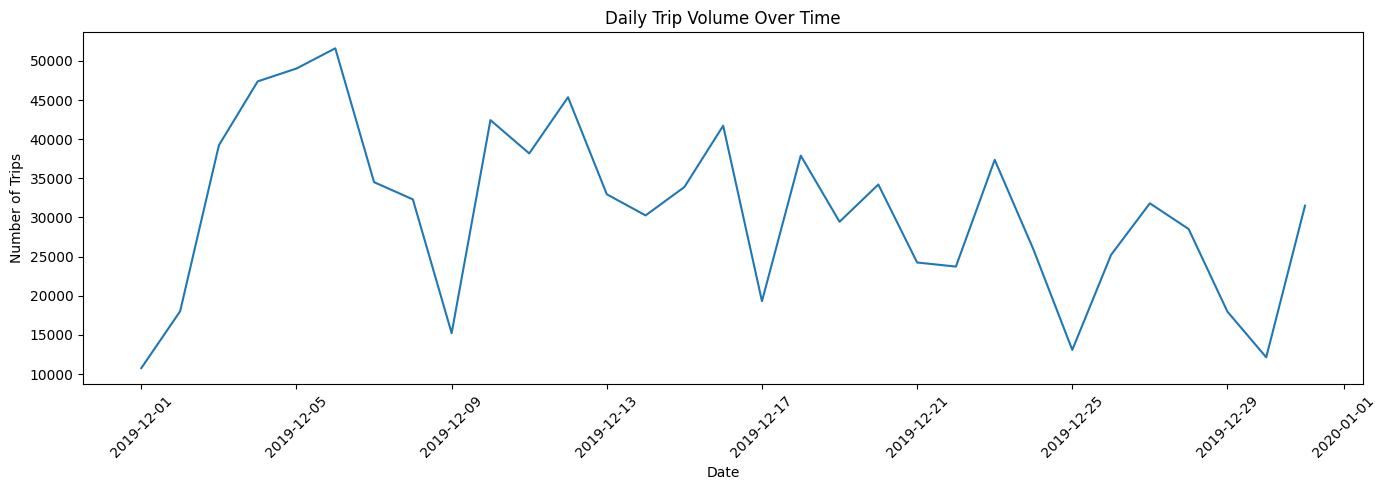

In [ ]:
import matplotlib.pyplot as plt

# Extract the date and count trips per day
daily_trips = bike_df.groupby(bike_df['starttime'].dt.date).size()

# Plot
plt.figure(figsize=(14, 5))
plt.plot(daily_trips.index, daily_trips.values)
plt.title('Daily Trip Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Total trip count and average trip duration broken down by User Type**

In [ ]:
# Calculate trip count and average duration by user type
bike_trips = bike_df.groupby('usertype')['tripduration'].agg(['count', 'mean']).round(2)

# Rename columns for readability
bike_trips.rename(columns={
    'count': 'total_trips',
    'mean': 'average_trip_duration',
})

,total_trips,average_trip_duration
usertype,,
Customer,77625,34.84
Subscriber,877585,11.99


Checking the total total count and average trip duration by user type, we see that Subscribers made up a much larger portion of the total rides, but take much shorter trips than Customers on average. In fact, the average trip by a customer is **2.9 times longer** than the average trip taken by a subscriber. How interesting!

**The most popular start and end station pairs**

In [ ]:
# Find the most popular start/end station pairs
station_pairs = bike_df.groupby(['start station name', 'end station name']).size().reset_index(name='trip_count')

# Sort by trip count
station_pairs = station_pairs.sort_values('trip_count', ascending=False)

station_pairs.head(10)

,start station name,end station name,trip_count
61484,E 7 St & Avenue A,Cooper Square & Astor Pl,456
115587,W 21 St & 6 Ave,9 Ave & W 22 St,397
28457,Broadway & W 60 St,11 Ave & W 59 St,384
52204,E 32 St & Park Ave,E 33 St & 1 Ave,351
59871,E 6 St & Avenue B,Cooper Square & Astor Pl,336
116078,W 22 St & 10 Ave,W 22 St & 8 Ave,290
3364,11 Ave & W 41 St,8 Ave & W 33 St,284
52108,E 32 St & Park Ave,2 Ave & E 31 St,274
3293,11 Ave & W 27 St,W 26 St & 8 Ave,273
110615,Vesey Pl & River Terrace,North Moore St & Greenwich St,264


**Bike usage by day of the week**

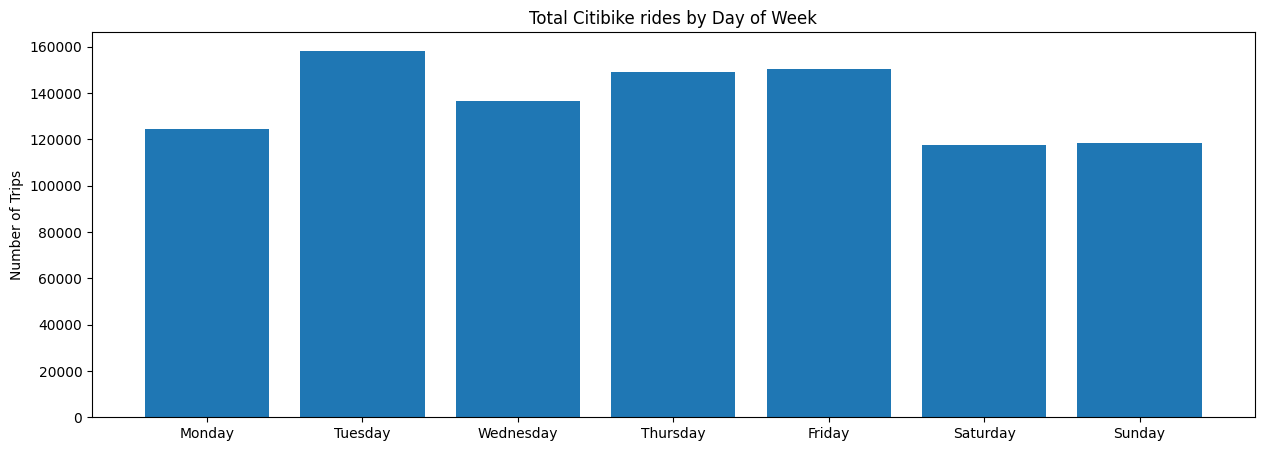

In [ ]:
# Get day of the week from the starttime column
bike_df['day_of_week'] = bike_df['starttime'].dt.day_name()

# Count trips per day of the week
daily_ridership = bike_df.groupby('day_of_week').size().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

# Plot as a bar chart
plt.figure(figsize=(15, 5))
plt.bar(daily_ridership.index, daily_ridership.values)
plt.title('Total Citibike rides by Day of Week')
plt.ylabel('Number of Trips')
plt.show()

#**Collaboration Plan**
We are using a shared Google Colab notebook in Google Drive so we can both work on the code at the same time. We meet 2 times a week in the library to go over what we have done, split up tasks, and make sure we are on the same page. Before Milestone 2 we want to finish cleaning both datasets, get our five summary stats computed, and have the first draft of our time series charts ready. After that we will focus on deeper analysis, better visualizations, and putting together the final presentation. We really want to maximize time spent working together to ensure we are on the same page and contribute equally to this assignment

